In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.basemap import Basemap

from watobs import CMEMSSatObsRepository

import copernicusmarine

# First time users
First time users of the Copernicus Marine API will need to create an account at https://marine.copernicus.eu/ and generate an API key.

Below you call the login function to authenticate your credentials. You only have to do this the first time you use the API on a PC.



In [2]:
if not CMEMSSatObsRepository.validate_login():
    copernicusmarine.login()

# First time users
First time users of the Copernicus Marine API will need to create an account at https://marine.copernicus.eu/ and generate an API key.

Below you call the login function to authenticate your credentials. You only have to do this the first time you use the API on a PC.



# Introduction to CMEMS Scatterometry Data
## Basic workflow process

#### Step 1
Define which dataset you are interested in by creating a repository object. You can either specify a `product_id` to download multiple satellites at once, or a `dataset_id` to download a single satellite.
> ```python
> repo = CMEMSSatObsRepository(product_id="...") # or dataset_id="..."
> ```

#### Step 2
Download the data for your area and time period of interest. The data is returned as a `watobs.AltimetryData` object.
> ```python
> data = repo.get_observation_stats(
>     start_date="YYYY-MM-DD", 
>     end_date="YYYY-MM-DD", 
>     area = f"bbox={lon_min},{lat_min},{lon_max},{lat_max}",
> )
> ```

#### Step 3
Plot, export, etc. It's your data now!

## Available datasets
### Specify dataset of product to be downloaded from CMEMS Online Catalogue
- Click through the catalogue here: https://data.marine.copernicus.eu/products?pk_vid=bfd50509683fc0421764148768aca348 

Downloading **multiple satellites** at once: Options are currently: **`product_id`**`=...`
- Waves
  - "WAVE_GLO_PHY_SWH_L3_MY_014_005" 
  - "WAVE_GLO_PHY_SWH_L3_NRT_014_001"
- Wind
  - "WIND_GLO_PHY_L3_MY_012_005" 
  - "WIND_GLO_PHY_L3_NRT_012_002"
- Spectral wave parameters (CFOSAT). For now, we only provide Hm0, Tp and PWD
  - "WAVE_GLO_PHY_SPC_L3_NRT_014_009"

Downloading **a single satellite** e.g. **`dataset_id`**`='cmems_obs-wind_glo_phy_nrt_l3-hy2b-hscat-asc-0.25deg_P1D-i'`
- Too many to list here!

Ideally there would be a better way to specify this in the future

# Examples

## Scatterometer Wind
Wide swath data

In [3]:
repo = CMEMSSatObsRepository(product_id="WIND_GLO_PHY_L3_NRT_012_002")

# OR

repo = CMEMSSatObsRepository(dataset_id='cmems_obs-wind_glo_phy_nrt_l3-hy2b-hscat-asc-0.25deg_P1D-i')

Loading CMEMS product id: WIND_GLO_PHY_L3_NRT_012_002
	Done!
Loading CMEMS dataset id: cmems_obs-wind_glo_phy_nrt_l3-hy2b-hscat-asc-0.25deg_P1D-i
	Done!


In [4]:
repo.get_observation_stats()

,min_date,max_date
short_name,,
hy2b,2020-11-11 00:00:00+00:00,2025-12-03 00:00:00+00:00


C:\Working\Coding\Repos\watobs\watobs\altimetry.py:297: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  yearly = pd.date_range(start="1984-1-1", end=end_date, freq="2AS")


<Axes: title={'center': 'Satellite lifespan'}>

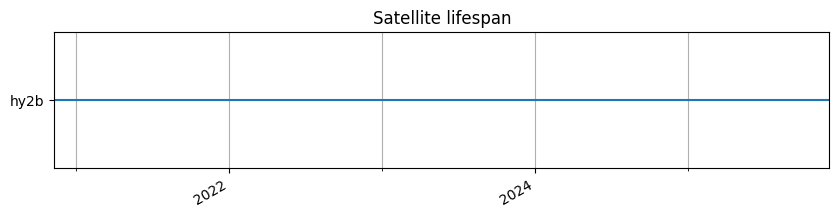

In [5]:
repo.plot_observation_stats()

### Datasets from product `WIND_GLO_PHY_L3_NRT_012_002`
- A total of 16 datasets, i.e. data from 8 different satellite missions, 2 orbits (asc/desc) each, are available in the catalogue for this product. (32 datasets if you include the coarser resolutions)

In [6]:
datasets = repo.datasets
datasets.head()

,source,source_type,obs_type,coverage,ocean_category,param,multiyear_or_nearrealtime,short_name,processing_level,asc_desc,spatial_resolution,temporal_resolution,temporal_type,min_date,max_date
dataset_id,,,,,,,,,,,,,,,
cmems_obs-wind_glo_phy_nrt_l3-hy2b-hscat-asc-0.25deg_P1D-i,cmems,obs,wind,glo,phy,None,nrt,hy2b,l3,asc,0.25deg,P1D,i,2020-11-11 00:00:00+00:00,2025-12-03 00:00:00+00:00


### Lets just choose the first satellite mission for simplicity
- In this case, i am interested in data from 2019 only
- In addition i want to see data in the North Sea west of the Danish coastline

In [7]:
start_time="2021-01-01"
end_time="2021-01-31"

lon_min = 6
lon_max = 9
lat_min = 55
lat_max = 57.5

area = f"bbox={lon_min},{lat_min},{lon_max},{lat_max}"

In [8]:
data = repo.get_satobs_data(
   #dataset_id=dataset, # we can disable this comment to download one dataset at a time
    start_time=start_time,
    end_time=end_time,
    area=area,
)

-- Downloading subset of cmems_obs-wind_glo_phy_nrt_l3-hy2b-hscat-asc-0.25deg_P1D-i


INFO - 2025-12-05T09:00:17Z - Selected dataset version: "202311"
INFO - 2025-12-05T09:00:17Z - Selected dataset part: "default"
INFO - 2025-12-05T09:00:24Z - Starting download. Please wait...
INFO - 2025-12-05T09:00:35Z - Successfully downloaded to c:\Working\Coding\Repos\watobs\notebooks\.cmems_2z_zo__y\cmems_obs-wind_glo_phy_nrt_l3-hy2b-hscat-asc-0.25deg_P1D-i_multi-vars_6.12E-8.88E_55.12N-57.38N_2021-01-01-2021-01-31.nc


-- Download successful.
Formatting data to DataFrame...
	Done!


In [9]:
data

### Data downloaded
- And it took 25-30 seconds for a year worth of wind speeds, directions and vector components

### Plotting
- Lets plot and see the data

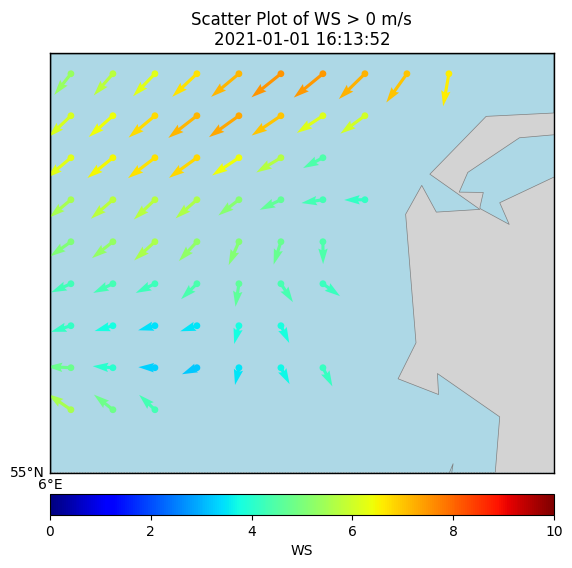

In [10]:
# Subset
df = data.df
timestep_2_plot = df.index.unique()[1]
df_subset = df.loc[df.index.unique()[1]]

# Define bounding box
dxm = 20
lon_0 = 0.5 * (lon_min + lon_max)
lat_0 = 0.5 * (lat_min + lat_max)

plt.figure(figsize=(10, 6))

# Initialize Basemap
m = Basemap(projection='cyl',
            lon_0=lon_0, lat_0=lat_0,
            llcrnrlon=lon_min, llcrnrlat=lat_min,
            urcrnrlon=lon_max, urcrnrlat=lat_max,
            resolution='l')

# Draw map features
m.drawcoastlines(color='gray', linewidth=0.5)
m.fillcontinents(color='lightgray', lake_color='lightblue')
m.drawmapboundary(fill_color='lightblue')

# Draw parallels and meridians
m.drawparallels(np.arange(lat_min, lat_max + dxm, dxm),
                labels=[1, 0, 0, 0], linewidth=0.5, color='lightgray', dashes=[2, 2])
m.drawmeridians(np.arange(lon_min, lon_max + dxm, dxm),
                labels=[0, 0, 0, 1], linewidth=0.5, color='lightgray', dashes=[2, 2])

# Prepare coordinates
x, y = m(df_subset['longitude'].values, df_subset['latitude'].values)

# Scatter plot with alpha mask
cs = m.scatter(x, y, c=df_subset['WS'], s=15, marker='o',
    cmap=plt.cm.jet, vmin=0, vmax=10)

# Vector plot of wind direction
u = df_subset['WS'] * np.cos(np.radians(df_subset['WD']))
v = df_subset['WS'] * np.sin(np.radians(df_subset['WD']))
norm = plt.Normalize(vmin=0, vmax=10)
m.quiver(x, y, u, v, df_subset['WS'], scale=100,  cmap=plt.cm.jet, norm=norm)

# Colorbar
cbar = m.colorbar(cs, location='bottom', pad="5%")
cbar.set_label('WS')

plt.title(f'Scatter Plot of WS > 0 m/s\n{timestep_2_plot}')
plt.show()

## Waves


In [11]:
repo = CMEMSSatObsRepository(product_id="WAVE_GLO_PHY_SWH_L3_NRT_014_001")

Loading CMEMS product id: WAVE_GLO_PHY_SWH_L3_NRT_014_001
	Done!


In [12]:
repo.get_observation_stats()

,min_date,max_date
short_name,,
al,2021-01-01 00:27:03+00:00,2025-12-05 06:18:31+00:00
c2,2021-01-01 00:00:00+00:00,2025-12-05 06:53:48+00:00
cfo,2021-01-01 00:34:11+00:00,2025-12-05 04:16:19+00:00
h2b,2021-01-01 00:00:00+00:00,2025-12-03 22:30:52+00:00
h2c,2022-12-01 01:07:06+00:00,2025-12-03 22:49:17+00:00
j3,2021-01-01 00:08:17+00:00,2025-12-05 03:28:00+00:00
s3a,2021-01-01 00:14:33+00:00,2025-12-05 05:57:09+00:00
s3b,2021-01-01 00:00:39+00:00,2025-12-05 06:56:58+00:00
s6a,2021-09-21 00:02:30+00:00,2025-12-05 05:30:36+00:00


C:\Working\Coding\Repos\watobs\watobs\altimetry.py:297: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  yearly = pd.date_range(start="1984-1-1", end=end_date, freq="2AS")


<Axes: title={'center': 'Satellite lifespan'}>

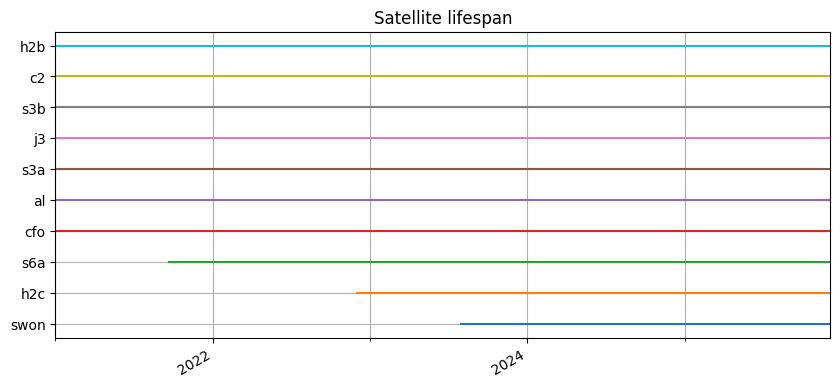

In [13]:
repo.plot_observation_stats()

### Download

In [14]:
start_time="2021-01-01"
end_time="2021-12-31"

lon_min = 6
lon_max = 9
lat_min = 55
lat_max = 57.5

area = f"bbox={lon_min},{lat_min},{lon_max},{lat_max}"

In [15]:
data = repo.get_satobs_data(
    #dataset_id=dataset, # we can disable this comment to download one dataset at a time
    start_time=start_time,
    end_time=end_time,
    area=area,
)

-- Downloading subset of cmems_obs-wave_glo_phy-swh_nrt_al-l3_PT1S


INFO - 2025-12-05T09:00:46Z - Selected dataset version: "202211"
INFO - 2025-12-05T09:00:46Z - Selected dataset part: "default"
WARNING - 2025-12-05T09:00:46Z - Some of your subset selection [2021-01-01 00:00:00+00:00, 2021-12-31 00:00:00+00:00] for the time dimension exceed the dataset coordinates [2021-01-01 00:27:03+00:00, 2025-12-05 06:18:31+00:00]


-- Download successful.
Formatting data to DataFrame...
<_io.BufferedReader name='c:\\Working\\Coding\\Repos\\watobs\\notebooks\\.cmems_2h0gx40b\\cmems_obs-wave_glo_phy-swh_nrt_al-l3_PT1S_VAVH-VAVH_UNFILTERED-WIND_SPEED_6.00E-9.00E_55.00N-57.50N_2021-01-01-2021-12-31.csv'>
	Done!
-- Downloading subset of cmems_obs-wave_glo_phy-swh_nrt_c2-l3_PT1S


INFO - 2025-12-05T09:01:00Z - Selected dataset version: "202211"
INFO - 2025-12-05T09:01:00Z - Selected dataset part: "default"


-- Download successful.
Formatting data to DataFrame...
<_io.BufferedReader name='c:\\Working\\Coding\\Repos\\watobs\\notebooks\\.cmems_2h0gx40b\\cmems_obs-wave_glo_phy-swh_nrt_c2-l3_PT1S_VAVH-VAVH_UNFILTERED-WIND_SPEED_6.00E-9.00E_55.00N-57.50N_2021-01-01-2021-12-31.csv'>
	Done!
-- Downloading subset of cmems_obs-wave_glo_phy-swh_nrt_cfo-l3_PT1S


...

-- Download successful.
Formatting data to DataFrame...
<_io.BufferedReader name='c:\\Working\\Coding\\Repos\\watobs\\notebooks\\.cmems_2h0gx40b\\cmems_obs-wave_glo_phy-swh_nrt_s3a-l3_PT1S_VAVH-VAVH_UNFILTERED-WIND_SPEED_6.00E-9.00E_55.00N-57.50N_2021-01-01-2021-12-31.csv'>
	Done!
-- Downloading subset of cmems_obs-wave_glo_phy-swh_nrt_s3b-l3_PT1S


INFO - 2025-12-05T09:02:02Z - Selected dataset version: "202211"
INFO - 2025-12-05T09:02:02Z - Selected dataset part: "default"
WARNING - 2025-12-05T09:02:02Z - Some of your subset selection [2021-01-01 00:00:00+00:00, 2021-12-31 00:00:00+00:00] for the time dimension exceed the dataset coordinates [2021-01-01 00:00:39+00:00, 2025-12-05 06:56:58+00:00]


-- Download successful.
Formatting data to DataFrame...
<_io.BufferedReader name='c:\\Working\\Coding\\Repos\\watobs\\notebooks\\.cmems_2h0gx40b\\cmems_obs-wave_glo_phy-swh_nrt_s3b-l3_PT1S_VAVH-VAVH_UNFILTERED-WIND_SPEED_6.00E-9.00E_55.00N-57.50N_2021-01-01-2021-12-31.csv'>
	Done!
-- Downloading subset of cmems_obs-wave_glo_phy-swh_nrt_s6a-l3_PT1S


INFO - 2025-12-05T09:02:16Z - Selected dataset version: "202211"
INFO - 2025-12-05T09:02:16Z - Selected dataset part: "default"
WARNING - 2025-12-05T09:02:16Z - Some of your subset selection [2021-09-21 00:00:00+00:00, 2021-12-31 00:00:00+00:00] for the time dimension exceed the dataset coordinates [2021-09-21 00:02:30+00:00, 2025-12-05 05:30:36+00:00]

-- Download successful.
Formatting data to DataFrame...
<_io.BufferedReader name='c:\\Working\\Coding\\Repos\\watobs\\notebooks\\.cmems_2h0gx40b\\cmems_obs-wave_glo_phy-swh_nrt_s6a-l3_PT1S_VAVH-VAVH_UNFILTERED-WIND_SPEED_6.00E-9.00E_55.00N-57.50N_2021-09-21-2021-12-31.csv'>
	Done!


### Data downloaded
- And it took 25-30 seconds for a year worth of wind speeds, directions and vector components

In [16]:
data.df.head()

,longitude,latitude,SWH,value_qc,satellite
time,,,,,
2021-01-05 04:26:15,8.749426,57.153362,1.448,1,al
2021-01-05 04:26:16,8.713835,57.213127,1.510,1,al
2021-01-05 04:26:17,8.678142,57.272884,1.649,1,al
2021-01-05 04:26:18,8.642348,57.332630,1.810,1,al
2021-01-05 04:26:19,8.606452,57.392370,1.943,1,al


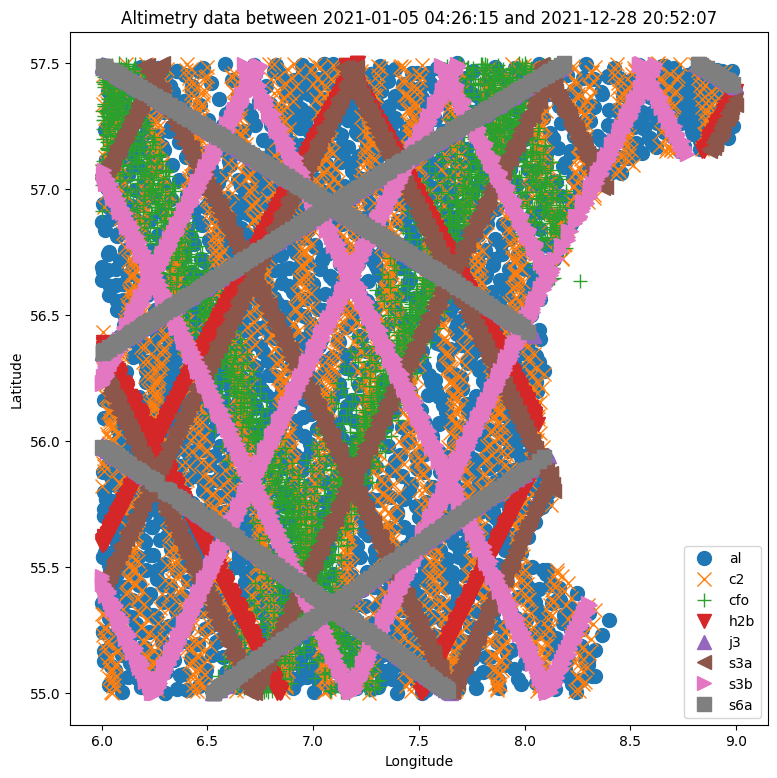

In [17]:
data.plot_map()

### Plotting
- Lets plot and see the data

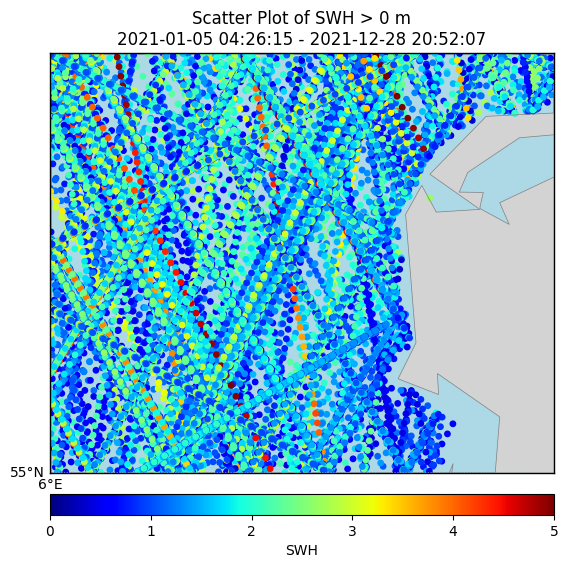

In [18]:
# Subset
df = data.df
timestep_2_plot = df.index.unique()[1]
df_subset = df.copy()

# Define bounding box
dxm = 20
lon_0 = 0.5 * (lon_min + lon_max)
lat_0 = 0.5 * (lat_min + lat_max)

plt.figure(figsize=(10, 6))

# Initialize Basemap
m = Basemap(projection='cyl',
            lon_0=lon_0, lat_0=lat_0,
            llcrnrlon=lon_min, llcrnrlat=lat_min,
            urcrnrlon=lon_max, urcrnrlat=lat_max,
            resolution='l')

# Draw map features
m.drawcoastlines(color='gray', linewidth=0.5)
m.fillcontinents(color='lightgray', lake_color='lightblue')
m.drawmapboundary(fill_color='lightblue')

# Draw parallels and meridians
m.drawparallels(np.arange(lat_min, lat_max + dxm, dxm),
                labels=[1, 0, 0, 0], linewidth=0.5, color='lightgray', dashes=[2, 2])
m.drawmeridians(np.arange(lon_min, lon_max + dxm, dxm),
                labels=[0, 0, 0, 1], linewidth=0.5, color='lightgray', dashes=[2, 2])

# Prepare coordinates
x, y = m(df_subset['longitude'].values, df_subset['latitude'].values)

# Scatter plot with alpha mask
cs = m.scatter(x, y, c=df_subset['SWH'], s=15, marker='o',
    cmap=plt.cm.jet, vmin=0, vmax=5)

# Colorbar
cbar = m.colorbar(cs, location='bottom', pad="5%")
cbar.set_label('SWH')

plt.title(f'Scatter Plot of SWH > 0 m\n{df.index[0]} - {df.index[-1]}')
plt.show()

## Spectral Parameters
Unfortuantely the spectral parameters do not have subsetting as an option. So even if you specify a bounding box, the entire dataset will be downloaded. You can however specify a time range, and it will download by month chunks.

In [19]:
repo = CMEMSSatObsRepository(product_id="WAVE_GLO_PHY_SPC_L3_NRT_014_009")

Loading CMEMS product id: WAVE_GLO_PHY_SPC_L3_NRT_014_009
	Done!


In [20]:
repo.get_observation_stats()

No time coordinates found in part 'default'.


,min_date,max_date
short_name,,
cfo,None,None


In [21]:
repo.datasets

No time coordinates found in part 'default'.


,source,source_type,obs_type,coverage,ocean_category,param,multiyear_or_nearrealtime,short_name,processing_level,asc_desc,spatial_resolution,temporal_resolution,temporal_type,min_date,max_date
dataset_id,,,,,,,,,,,,,,,
cnes_obs-wave_glo_phy-spc_nrt_cfo-l3_PT10S,cnes,obs,wave,glo,phy,spc,nrt,cfo,l3,None,None,PT10S,None,None,None


To keep things simple and fast, we will use the `filter` kwarg to only download data for a specific day and time, specifically `2021-01-01`


In [22]:
data = repo.get_satobs_data(
    filter = f"*/2021/01/*20210101*"
)

No time coordinates found in part 'default'.


INFO - 2025-12-05T09:02:33Z - Selected dataset version: "202406"
INFO - 2025-12-05T09:02:33Z - Selected dataset part: "default"
INFO - 2025-12-05T09:02:35Z - Listing files on remote server...
45it [00:22,  2.04it/s]
Empty data from cnes_obs-wave_glo_phy-spc_nrt_cfo-l3_PT10S_20210101T032016Z_20210101T033158Z_P20240516T142100Z.nc, skipping


Formatting data to DataFrame...
Merging files for 2021
	Done!
No time coordinates found in part 'default'.


Other options to try:

```python
# Download all data between 1 January 2021 and 31 December 2021
data = repo.get_satobs_data(
    start_time="2021-01-01",
    end_time="2021-12-31"
)

```

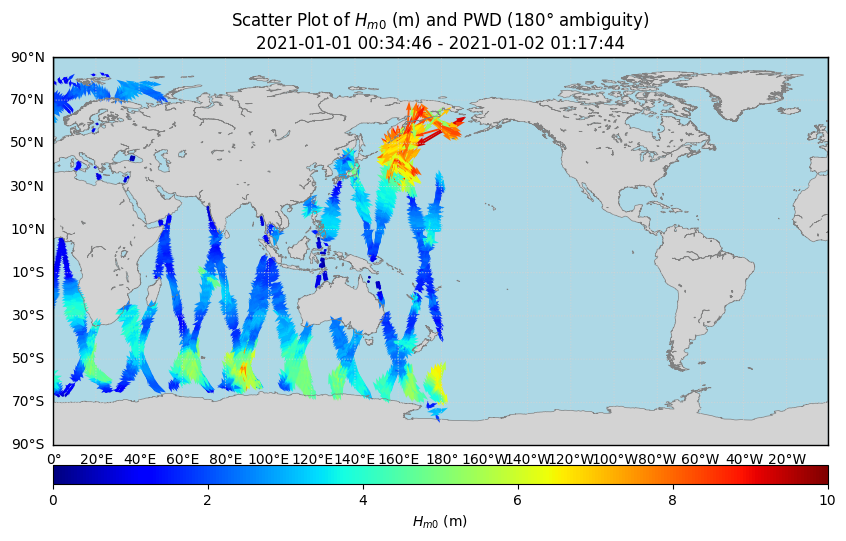

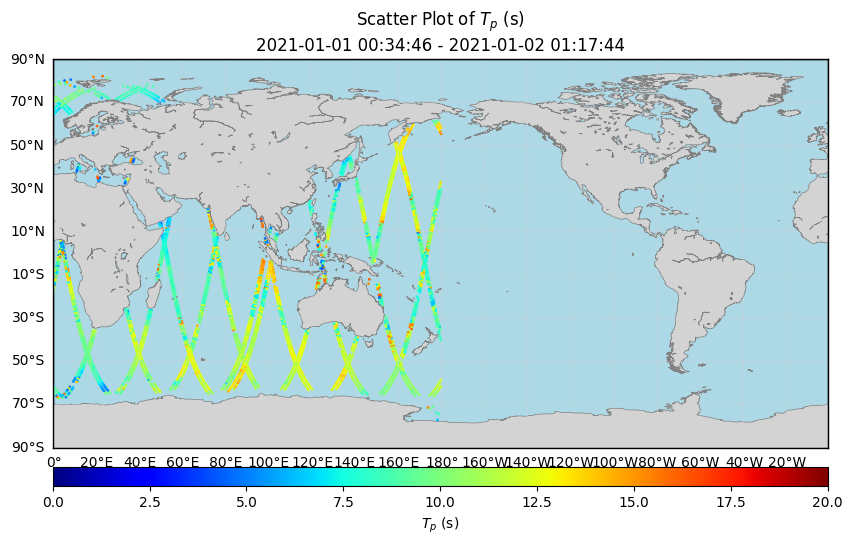

In [23]:
df = data.df
# Define bounding box
dxm = 20
lon_min = 0
lon_max = 359
lat_min = -90
lat_max = 90
lon_0 = 0.5 * (lon_min + lon_max)
lat_0 = 0.5 * (lat_min + lat_max)

plt_sts = {
    'SWH' : {'scale': 250, 'vmin': 0, 'vmax': 10, 'label': '$H_{m0}$ (m)'},
    'TP'  : {'scale': 750,  'vmin': 0, 'vmax': 20, 'label': '$T_p$ (s)'},
}

for var in ['SWH','TP']:
    plt.figure(figsize=(10, 6))

    # Initialize Basemap
    m = Basemap(projection='cyl',
                lon_0=lon_0, lat_0=lat_0,
                llcrnrlon=lon_min, llcrnrlat=lat_min,
                urcrnrlon=lon_max, urcrnrlat=lat_max,
                resolution='l')

    # Draw map features
    m.drawcoastlines(color='gray', linewidth=0.5)
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')

    # Draw parallels and meridians
    m.drawparallels(np.arange(lat_min, lat_max + dxm, dxm),
                    labels=[1, 0, 0, 0], linewidth=0.5, color='lightgray', dashes=[2, 2])
    m.drawmeridians(np.arange(lon_min, lon_max + dxm, dxm),
                    labels=[0, 0, 0, 1], linewidth=0.5, color='lightgray', dashes=[2, 2])

    # Prepare coordinates
    x, y = m(df['longitude'].values, df['latitude'].values)

    # Scatter plot with alpha mask
    cs = m.scatter(x, y, c=df[var], s=1, marker='o',
                cmap=plt.cm.jet, vmin=plt_sts[var]['vmin'], vmax=plt_sts[var]['vmax'])
    if var=='SWH':
        # Vector plot of wind direction
        u = df[var] * np.cos(np.radians(df['PWD']))
        v = df[var] * np.sin(np.radians(df['PWD']))
        norm = plt.Normalize(vmin=plt_sts[var]['vmin'], vmax=plt_sts[var]['vmax'])
        m.quiver([x,x], [y,y], [u,-u], [v,-v], [df[var],df[var]], scale=plt_sts[var]['scale'],  cmap=plt.cm.jet, norm=norm)

        plt.title(f'Scatter Plot of {plt_sts[var]["label"]} and PWD (180° ambiguity)\n{df.index[0]} - {df.index[-1]}')
    else:
        plt.title(f'Scatter Plot of {plt_sts[var]["label"]}\n{df.index[0]} - {df.index[-1]}')


    # Colorbar
    cbar = m.colorbar(cs, location='bottom', pad="5%")
    cbar.set_label(plt_sts[var]['label'])

    
    plt.show()

## One big `wind` dataset...
Download the whole globe

In [25]:
repo = CMEMSSatObsRepository(dataset_id='cmems_obs-wind_glo_phy_nrt_l3-hy2b-hscat-asc-0.25deg_P1D-i')
data = repo.get_satobs_data(
                                                    start_time="2021-01-01",
                                                    end_time="2021-01-31")

Loading CMEMS dataset id: cmems_obs-wind_glo_phy_nrt_l3-hy2b-hscat-asc-0.25deg_P1D-i
	Done!
- Downloading January 2021


INFO - 2025-12-05T09:31:31Z - Selected dataset version: "202311"
INFO - 2025-12-05T09:31:31Z - Selected dataset part: "default"
INFO - 2025-12-05T09:31:32Z - Listing files on remote server...
2it [00:01,  1.02it/s]


Formatting data to DataFrame...
Merging files for 2021
	Done!


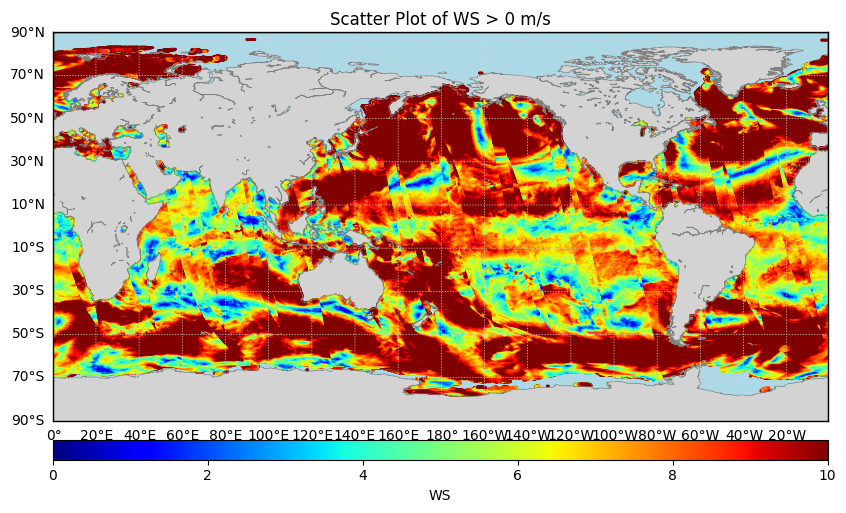

In [26]:
df = data.df
# Define bounding box
dxm = 20
lon_min = 0
lon_max = 359
lat_min = -90
lat_max = 90
lon_0 = 0.5 * (lon_min + lon_max)
lat_0 = 0.5 * (lat_min + lat_max)

plt.figure(figsize=(10, 6))

# Initialize Basemap
m = Basemap(projection='cyl',
            lon_0=lon_0, lat_0=lat_0,
            llcrnrlon=lon_min, llcrnrlat=lat_min,
            urcrnrlon=lon_max, urcrnrlat=lat_max,
            resolution='l')

# Draw map features
m.drawcoastlines(color='gray', linewidth=0.5)
m.fillcontinents(color='lightgray', lake_color='lightblue')
m.drawmapboundary(fill_color='lightblue')

# Draw parallels and meridians
m.drawparallels(np.arange(lat_min, lat_max + dxm, dxm),
                labels=[1, 0, 0, 0], linewidth=0.5, color='lightgray', dashes=[2, 2])
m.drawmeridians(np.arange(lon_min, lon_max + dxm, dxm),
                labels=[0, 0, 0, 1], linewidth=0.5, color='lightgray', dashes=[2, 2])

# Prepare coordinates
x, y = m(df['longitude'].values, df['latitude'].values)

# Create alpha mask: transparent if WS == 0.5
alpha_values = np.where(df['WS'] < 0.01, 0.0, 1.0)

# Scatter plot with alpha mask
cs = m.scatter(x, y, c=df['WS'], s=1, marker='o',
               cmap=plt.cm.jet, vmin=0, vmax=10,
               alpha=alpha_values)

# Colorbar
cbar = m.colorbar(cs, location='bottom', pad="5%")
cbar.set_label('WS')

plt.title('Scatter Plot of WS > 0 m/s')
plt.show()